In [24]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [39]:
df_long = pd.read_csv('df_long_sucio.csv')

C:\Users\felip\AppData\Local\Temp\ipykernel_6216\3955116605.py:23: FutureWarning: This dataframe has a column name that matches the 'value_name' column name of the resulting Dataframe. In the future this will raise an error, please set the 'value_name' parameter of DataFrame.melt to a unique name.
  df_panel1 = df_resumen.melt(


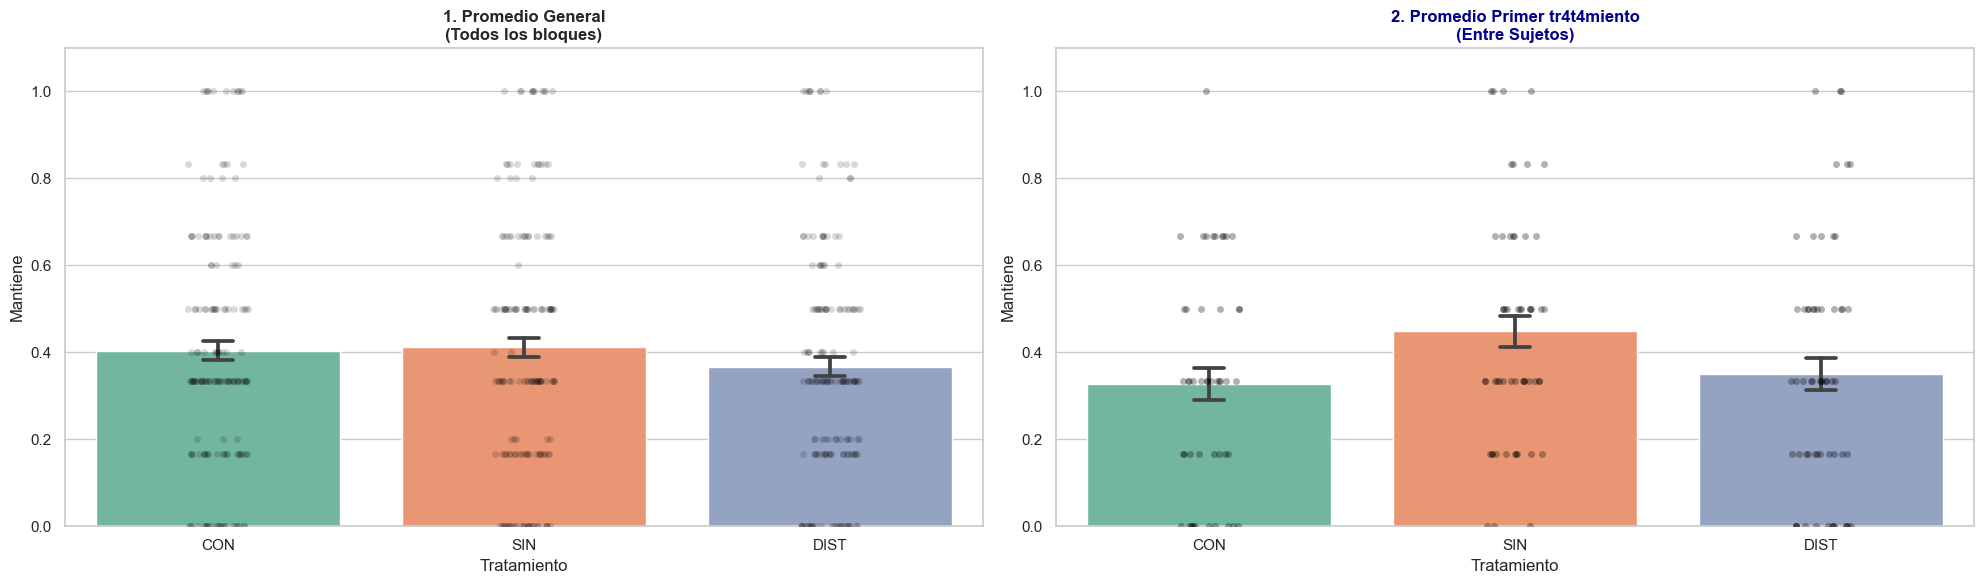


 RESULTADOS ACTUALIZADOS (MUESTRA TOTAL)

--- 1. Intra-sujetos (Promedio General) ---
             count   mean    sem
Tratamiento                     
CON            162  0.404  0.022
SIN            162  0.411  0.023
DIST           162  0.367  0.021

--- 2. Entre-sujetos (Promedio Primer Bloque Completo) ---
             count   mean    sem
Tratamiento                     
CON             48  0.326  0.037
SIN             55  0.448  0.036
DIST            59  0.350  0.037


In [40]:
# Calculamos los promedios y los pegamos directamente al df_long
# Usamos pivot_table y add_prefix para crear las columnas de una sola vez
df_long = df_long.merge(
    df_long.pivot_table(index='ID_Sujeto', columns='Dilema', values='Mantiene', aggfunc='mean')
           .add_prefix('Promedio_'), 
    on='ID_Sujeto'
)

# Creamos el df_resumen (una fila por sujeto)
df_resumen = df_long.drop_duplicates(subset=['ID_Sujeto']).copy()

# Limpieza opcional: si quieres que el índice sea el ID_Sujeto
#df_resumen.set_index('ID_Sujeto', inplace=True)

# --- PRE-PROCESAMIENTO ---

# A. Para Paneles 2 y 3 (df_long): Limpieza de duplicados y extracción de tratamiento
df_long = df_long.drop_duplicates(subset=['ID_Sujeto', 'Orden_1', 'Orden_2'], keep='first').copy()
df_long['Tratamiento'] = df_long['Dilema'].str.upper().str.extract('(CON|SIN|DIST)', expand=False)

# B. Para Panel 1 (df_resumen): Melt para formato largo
# Transformamos las columnas Promedio_X en filas
df_panel1 = df_resumen.melt(
    id_vars='ID_Sujeto', 
    value_vars=['Promedio_Bloque_CON', 'Promedio_Bloque_SIN', 'Promedio_Dist'],
    var_name='Tratamiento', 
    value_name='Mantiene'
)
df_panel1['Tratamiento'] = df_panel1['Tratamiento'].str.replace('Promedio_', '')


# --- PREPARACIÓN DE LOS 3 PANELES ---

# A. Panel 1: Promedio General (Intra-Sujetos)
df_panel1 = df_long.groupby(['ID_Sujeto', 'Tratamiento'])['Mantiene'].mean().reset_index()

# B. Panel 2: Promedio Primer Tratamiento (Entre-Sujetos)
df_panel2 = df_long[df_long['Orden_1'] == 1].groupby(['ID_Sujeto', 'Tratamiento'])['Mantiene'].mean().reset_index()

# C. Panel 3: Primera Reacción (Ensayo 1 del Bloque 1)
df_panel3 = df_long[(df_long['Orden_1'] == 1) & (df_long['Orden_2'] == 1)].copy()

# --- VISUALIZACIÓN ---
orden = ['CON', 'SIN', 'DIST']
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# Panel 1
sns.barplot(data=df_panel1, x='Tratamiento', y='Mantiene', order=orden, palette='Set2', errorbar='se', capsize=.1, ax=axes[0])
sns.stripplot(data=df_panel1, x='Tratamiento', y='Mantiene', order=orden, color='black', alpha=0.15, jitter=True, ax=axes[0])
axes[0].set_title('1. Promedio General\n(Todos los bloques)', fontsize=12, fontweight='bold')
axes[0].set_ylim(0, 1.1)

# Panel 2
sns.barplot(data=df_panel2, x='Tratamiento', y='Mantiene', order=orden, palette='Set2', errorbar='se', capsize=.1, ax=axes[1])
sns.stripplot(data=df_panel2, x='Tratamiento', y='Mantiene', order=orden, color='black', alpha=0.3, jitter=True, ax=axes[1])
axes[1].set_title('2. Promedio Primer tr4t4miento\n(Entre Sujetos)', fontsize=12, fontweight='bold', color='darkblue')
axes[1].set_ylim(0, 1.1)

plt.tight_layout()
plt.savefig('grafico_tratamiento_n162.png', dpi=300)
plt.show()

# --- TABLAS RESUMEN ---
print(f"\n{'='*60}")
print(" RESULTADOS ACTUALIZADOS (MUESTRA TOTAL)")
print(f"{'='*60}")

print("\n--- 1. Intra-sujetos (Promedio General) ---")
print(df_panel1.groupby('Tratamiento')['Mantiene'].agg(['count', 'mean', 'sem']).reindex(orden).round(3))

print("\n--- 2. Entre-sujetos (Promedio Primer Bloque Completo) ---")
print(df_panel2.groupby('Tratamiento')['Mantiene'].agg(['count', 'mean', 'sem']).reindex(orden).round(3))